# Post-Fire Watershed Vulnerability on Tribal Lands
**Series:** Tribal Fire Science & Indigenous Data Sovereignty  
**Author:** Lilly Jones, PhD  
**Last Updated:** 2025  
**Data Sources:** MTBS, USGS WBD HUC-8, USGS NHDPlus HR, Census TIGER AIANNH, OSM

## Overview
Fire does not end at the fire perimeter. In the months and years after a fire,
burned watersheds are highly vulnerable to erosion, debris flows, and drinking
water contamination. Tribal Nations in headwater areas, which for this series includes Warm Springs,
Colville, Fort Apache, and San Carlos face compounding risks when fire burns
upstream of water supply infrastructure.

This notebook quantifies post-fire watershed vulnerability by combining:
- MTBS burn history and severity per watershed (1984–present)
- USGS NHDPlus stream network within burned watersheds
- Water supply infrastructure proximity via OpenStreetMap
- A composite watershed vulnerability index

All analysis is vector-based: no raster downloads required. Burn severity
is estimated from the mean dNBR value reported in MTBS perimeter attributes.

## Research Questions
- Which Tribal watersheds have the highest post-fire erosion and contamination risk?
- Which watersheds burned recently (last 5 years) and remain in the high-risk window?
- Where is water supply infrastructure downstream of burned areas?

## Burn Severity Proxy
MTBS perimeters include `dNBRmnXcp`, the mean differenced Normalized Burn Ratio
excluding non-processing areas. This is used as a per-fire severity indicator:

| dNBR | Severity class |
|---|---|
| < 100 | Unburned / Low |
| 100–269 | Low |
| 270–439 | Moderate |
| > 439 | High = highest erosion and contamination risk |

## Data Sovereignty Note
> Fire history and watershed data are federal datasets. Water infrastructure
> locations from OSM may be incomplete for Tribal lands; consult Tribal water
> resource departments for authoritative infrastructure mapping.

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
from datetime import datetime

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import osmnx as ox
import pandas as pd
import seaborn as sns
from shapely.validation import make_valid

from src.data import constants, loaders, validators
from src.data.constants import PRIMARY_TRIBES
from src.geo import utils as geo_utils
from src.indigenous.sovereignty import generate_citations, print_data_acknowledgment
from src.viz import charts, styles

styles.apply_mpl_style()
%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

print(f"Repo root : {REPO_ROOT}")
print(f"Output dir: {constants.OUTPUTS_DIR}")
print(f"Analysis run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Repo root : C:\Users\gekek\Documents\tfs_refactor
Output dir: C:\Users\gekek\Documents\tfs_refactor\outputs
Analysis run: 2026-04-06 12:15


In [2]:
print_data_acknowledgment(source_keys=["census_aiannh", "mtbs", "usgs_wbd", "nhd_flowlines"])

DATA SOVEREIGNTY ACKNOWLEDGMENT
This analysis uses data that describes Indigenous and Tribal lands,
communities, and fire histories. This project is guided by three
complementary data governance frameworks:

OCAP®: Tribal Nations own, control, access, and possess data about
  their own communities and territories.
  Reference: https://fnigc.ca/ocap-training/

CARE: Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to communities,
  and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR: Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE and OCAP® govern the ethical
  obligations to Tribal Nations that FAIR alone does not address.
  Reference: https://www.go-fair.org/fair-principles/

Tribal Nations are sovereign governments with the right to control data about their own communities and territories.
Federal and third-pa

## Configuration

In [3]:
TRIBES_OF_INTEREST = PRIMARY_TRIBES

# Burn severity thresholds (dNBR)
DNBR_LOW      = 100
DNBR_MODERATE = 270
DNBR_HIGH     = 439

# Recent burn window (years from analysis date)
RECENT_BURN_YEARS = 5
ANALYSIS_YEAR     = 2024
RECENT_CUTOFF     = ANALYSIS_YEAR - RECENT_BURN_YEARS  # 2019

# Minimum stream order for network analysis (3 = perennial streams)
MIN_STREAM_ORDER = 3

# Buffer around watershed outlet to search for water infrastructure
WATER_INFRA_BUFFER_KM = 10

print(f"Analysis target  : {len(TRIBES_OF_INTEREST)} Tribal Nations")
print(f"Recent burn window: {RECENT_CUTOFF}–{ANALYSIS_YEAR}")
print(f"High severity dNBR: > {DNBR_HIGH}")
print(f"Min stream order  : {MIN_STREAM_ORDER} (Strahler)")

Analysis target  : 10 Tribal Nations
Recent burn window: 2019–2024
High severity dNBR: > 439
Min stream order  : 3 (Strahler)


## Load Tribal Boundaries and Watersheds

In [4]:
# Tribal land boundaries 
all_tribal = loaders.load_census_aian()
all_tribal = validators.validate_geodataframe(
    all_tribal, "census_aiannh", required_columns=["geometry", "NAME"]
)
tribal_lands = all_tribal[all_tribal["NAME"].isin(TRIBES_OF_INTEREST)].copy()
tribal_lands = tribal_lands.dissolve(by="NAME", as_index=False).reset_index(drop=True)
tribal_lands["geometry"] = tribal_lands.geometry.apply(
    lambda g: make_valid(g) if g is not None else g
)
CONUS = geo_utils.bbox_geodataframe((-127, 24, -65, 50)).geometry.iloc[0]
tribal_lands = tribal_lands[
    tribal_lands.geometry.notnull() &
    tribal_lands.geometry.is_valid &
    tribal_lands.intersects(CONUS)
].copy().reset_index(drop=True)

tribal_proj  = tribal_lands.to_crs("EPSG:5070")
tribal_lands["area_km2"] = tribal_proj.geometry.area / 1e6

BUFFER_DEG = 0.5
bounds      = tribal_lands.total_bounds
STUDY_BBOX  = (
    bounds[0] - BUFFER_DEG, bounds[1] - BUFFER_DEG,
    bounds[2] + BUFFER_DEG, bounds[3] + BUFFER_DEG,
)
print(f"Tribal Nations: {len(tribal_lands)}")

Tribal Nations: 10


In [5]:
# USGS WBD HUC-8 watersheds 
# Bbox-only query: WHERE and spatial filter causes 500 error on this endpoint.
# HUC2 filtering done in Python post-load.

# USGS WBD HUC-8 watersheds (per-Tribe bbox to avoid 500 error)
# Full study area bbox is too large for this endpoint.
# Query one small bbox per Tribal land and deduplicate.

ws_parts = []
BUF = 0.3

for _, tribe in tribal_lands.iterrows():
    tb   = tribe.geometry.bounds
    bbox = (tb[0]-BUF, tb[1]-BUF, tb[2]+BUF, tb[3]+BUF)
    try:
        ws = loaders.load_usgs_wbd_huc8(bbox=bbox, huc2_codes=None)
        if not ws.empty:
            ws_parts.append(ws)
        print(f"  {tribe['NAME']}: {len(ws)} watersheds")
    except Exception as e:
        print(f"  {tribe['NAME']}: failed — {e}")

if ws_parts:
    watersheds_raw = pd.concat(ws_parts, ignore_index=True).drop_duplicates(subset="huc8")
    watersheds = validators.validate_geodataframe(
        watersheds_raw, "usgs_wbd", required_columns=["geometry", "name"]
    )
    # Keep only HUC-2 regions relevant to PRIMARY_TRIBES
    HUC2_OF_INTEREST = ["11", "15", "17"]
    watersheds = watersheds[
        watersheds["huc8"].str[:2].isin(HUC2_OF_INTEREST)
    ].copy().reset_index(drop=True)
    watersheds["area_km2"] = watersheds.to_crs("EPSG:5070").geometry.area / 1e6
    print(f"\nHUC-8 watersheds loaded: {len(watersheds):,}")
else:
    raise RuntimeError("No WBD watershed data loaded. Check network access.")

  Cherokee: 25 watersheds
  Chickasaw: 28 watersheds
  Choctaw: 32 watersheds
  Colville: 15 watersheds
  Creek: 23 watersheds
  Fort Apache: 15 watersheds
  Kiowa-Comanche-Apache-Fort Sill Apache: 23 watersheds
  Osage: 16 watersheds
  San Carlos: 18 watersheds
  Warm Springs: 19 watersheds

HUC-8 watersheds loaded: 125


In [6]:
# Identify watersheds that overlap Tribal lands 
tribal_proj_5070 = tribal_lands.to_crs("EPSG:5070")
ws_proj_5070     = watersheds.to_crs("EPSG:5070")

ws_tribe = gpd.sjoin(
    ws_proj_5070[["huc8", "name", "area_km2", "geometry"]],
    tribal_proj_5070[["NAME", "geometry"]],
    how="inner",
    predicate="intersects",
).drop(columns=["index_right"], errors="ignore").reset_index(drop=True)

tribal_watersheds = (
    ws_tribe.drop_duplicates(subset="huc8")
    .merge(
        ws_tribe.groupby("huc8")["NAME"].apply(list).reset_index()
        .rename(columns={"NAME": "tribes"}),
        on="huc8",
    )
    .reset_index(drop=True)
)
tribal_watersheds = gpd.GeoDataFrame(tribal_watersheds, crs="EPSG:5070").to_crs(constants.CRS_GEOGRAPHIC)

print(f"Watersheds overlapping Tribal lands: {len(tribal_watersheds)}")
print(f"\nSample:")
tribal_watersheds[["huc8", "name", "area_km2"]].head()

Watersheds overlapping Tribal lands: 72

Sample:


,huc8,name,area_km2
0,11100302,Lower North Canadian,4842.717567
1,11110103,Illinois,4283.406518
2,11110105,Poteau,4934.415344
3,11090202,Lower Canadian-Walnut,4747.154799
4,11090203,Little,2530.819643


## Load MTBS Fire History and Compute Burn Statistics

In [7]:
# MTBS fire perimeters 
MTBS_LOCAL = constants.RAW_DIR / "mtbs_perimeters" / "mtbs_perims_DD.shp"

if not MTBS_LOCAL.exists():
    raise FileNotFoundError(
        "MTBS shapefile not found at data/raw/mtbs_perimeters/mtbs_perims_DD.shp\n"
        "Download from https://www.mtbs.gov/direct-download"
    )

fire_gdf = gpd.read_file(MTBS_LOCAL)
fire_gdf.columns = fire_gdf.columns.str.lower()
fire_gdf["ig_date"]   = pd.to_datetime(fire_gdf["ig_date"], errors="coerce")
fire_gdf["fire_year"] = fire_gdf["ig_date"].dt.year
fire_gdf["dnbr_mean"] = pd.to_numeric(fire_gdf.get("dnbrmnxcp", pd.Series()), errors="coerce")
fire_gdf = fire_gdf.to_crs(constants.CRS_GEOGRAPHIC)

# Clip to study area
study_poly = geo_utils.bbox_geodataframe(STUDY_BBOX).geometry.iloc[0]
fire_local = fire_gdf[fire_gdf.intersects(study_poly)].copy()

# Severity class from dNBR
def _severity_class(dnbr):
    if pd.isna(dnbr):      return "Unknown"
    if dnbr < DNBR_LOW:    return "Low"
    if dnbr < DNBR_MODERATE: return "Low"
    if dnbr < DNBR_HIGH:   return "Moderate"
    return                         "High"

fire_local["severity_class"] = fire_local["dnbr_mean"].apply(_severity_class)
fire_local["recent"]         = fire_local["fire_year"] >= RECENT_CUTOFF

print(f"MTBS fires in study area: {len(fire_local):,}")
print(f"  Recent ({RECENT_CUTOFF}+): {fire_local['recent'].sum()}")
print(f"  High severity: {(fire_local['severity_class'] == 'High').sum()}")
print(f"\nSeverity distribution:")
print(fire_local["severity_class"].value_counts().to_string())

MTBS fires in study area: 13,708
  Recent (2019+): 1961
  High severity: 0

Severity distribution:
severity_class
Unknown    13708


In [8]:
# Burn statistics per Tribal watershed 
ws_proj  = tribal_watersheds.to_crs("EPSG:5070")
fire_proj = fire_local.to_crs("EPSG:5070")

burn_records = []

for _, ws in ws_proj.iterrows():
    # Fires intersecting this watershed
    fires_in = fire_proj[fire_proj.intersects(ws.geometry)].copy()

    if fires_in.empty:
        burn_records.append({
            "huc8":              ws["huc8"],
            "fire_count":        0,
            "recent_fire_count": 0,
            "high_sev_count":    0,
            "mean_dnbr":         np.nan,
            "most_recent_year":  np.nan,
            "burned_area_km2":   0.0,
            "pct_watershed_burned": 0.0,
        })
        continue

    # Intersected burned area within watershed
    try:
        clipped_fires = fires_in.copy()
        clipped_fires["geometry"] = fires_in.geometry.intersection(ws.geometry)
        clipped_fires = clipped_fires[~clipped_fires.geometry.is_empty]
        burned_area_km2 = clipped_fires.geometry.area.sum() / 1e6
    except Exception:
        burned_area_km2 = fires_in.geometry.area.sum() / 1e6

    ws_area_km2 = ws.geometry.area / 1e6
    pct_burned  = min(burned_area_km2 / ws_area_km2 * 100, 100) if ws_area_km2 > 0 else 0

    burn_records.append({
        "huc8":                  ws["huc8"],
        "fire_count":            len(fires_in),
        "recent_fire_count":     int(fires_in["recent"].sum()),
        "high_sev_count":        int((fires_in["severity_class"] == "High").sum()),
        "mean_dnbr":             fires_in["dnbr_mean"].mean(),
        "most_recent_year":      fires_in["fire_year"].max(),
        "burned_area_km2":       round(burned_area_km2, 1),
        "pct_watershed_burned":  round(pct_burned, 1),
    })

burn_df = pd.DataFrame(burn_records)
tribal_watersheds = tribal_watersheds.merge(burn_df, on="huc8", how="left")

burned_ws = tribal_watersheds[tribal_watersheds["fire_count"] > 0]
print(f"Watersheds with fire history: {len(burned_ws)} of {len(tribal_watersheds)}")
print(f"Watersheds with recent fires : {(tribal_watersheds['recent_fire_count'] > 0).sum()}")
print(f"Watersheds with high severity: {(tribal_watersheds['high_sev_count'] > 0).sum()}")
print(f"\nTop watersheds by burned area %:")
print(
    tribal_watersheds[["name", "pct_watershed_burned", "recent_fire_count",
                         "high_sev_count", "mean_dnbr"]]
    .sort_values("pct_watershed_burned", ascending=False)
    .head(10)
    .to_string(index=False)
)

Watersheds with fire history: 70 of 72
Watersheds with recent fires : 64
Watersheds with high severity: 0

Top watersheds by burned area %:
           name  pct_watershed_burned  recent_fire_count  high_sev_count  mean_dnbr
   Chief Joseph                  87.4                 10               0        NaN
     San Carlos                  86.5                 23               0        NaN
Lower Deschutes                  71.4                  9               0        NaN
          Black                  69.7                 19               0        NaN
        Carrizo                  65.2                 10               0        NaN
           Bird                  61.6                 42               0        NaN
  North Santiam                  54.1                  3               0        NaN
    Lake Chelan                  47.3                  2               0        NaN
 Lower John Day                  36.8                  7               0        NaN
        Sanpoil     

## Load Stream Network

In [9]:
# NHDPlus HR flowlines per Tribal land bbox 
# Query order: 3+ streams (perennial) within each Tribal land's bounding box.
# Smaller bboxes avoid the large-area timeout issues seen with road networks.

print("Loading NHD stream network...")
stream_parts = []

for _, tribe in tribal_lands.iterrows():
    tb  = tribe.geometry.bounds
    buf = 0.1
    bbox = (tb[0]-buf, tb[1]-buf, tb[2]+buf, tb[3]+buf)
    try:
        streams = loaders.load_nhd_flowlines(
            bbox=bbox, min_stream_order=MIN_STREAM_ORDER
        )
        if not streams.empty:
            streams["tribal_name"] = tribe["NAME"]
            stream_parts.append(streams)
        print(f"  {tribe['NAME']}: {len(streams):,} stream segments")
    except Exception as e:
        print(f"  {tribe['NAME']}: failed — {e}")

if stream_parts:
    streams_gdf = pd.concat(stream_parts, ignore_index=True)
    streams_gdf = gpd.GeoDataFrame(streams_gdf, crs=constants.CRS_GEOGRAPHIC)
    streams_gdf = streams_gdf.drop_duplicates(subset=["ReachCode"]).reset_index(drop=True)
    print(f"\nTotal unique stream segments: {len(streams_gdf):,}")
else:
    streams_gdf = gpd.GeoDataFrame(
        columns=["ReachCode", "GNIS_Name", "StreamOrde", "geometry"],
        geometry="geometry", crs=constants.CRS_GEOGRAPHIC,
    )
    print("No stream data loaded.")

Loading NHD stream network...
  Cherokee: 0 stream segments
  Chickasaw: 0 stream segments
  Choctaw: 0 stream segments
  Colville: 0 stream segments
  Creek: 0 stream segments
  Fort Apache: 0 stream segments
  Kiowa-Comanche-Apache-Fort Sill Apache: 0 stream segments
  Osage: 0 stream segments
  San Carlos: 0 stream segments
  Warm Springs: 0 stream segments
No stream data loaded.


## Water Supply Infrastructure

In [10]:
# OSM water infrastructure: fixed-radius centroid query for large ROI
# Queries for water towers, water treatment plants, and water wells.
# OSM coverage of Tribal infrastructure is incomplete: results should be
# verified with Tribal water resource departments.

ox.settings.log_console = False
ox.settings.use_cache   = True

WATER_TAGS = {
    "man_made": ["water_tower", "water_works", "water_well", "storage_tank"],
    "amenity":  ["water_point"],
}
WATER_RADIUS_KM = 30

water_parts  = []
tribal_proj  = tribal_lands.to_crs("EPSG:5070")
print("Querying OSM for water supply infrastructure...")

for _, tribe in tribal_proj.iterrows():
    centroid_geo = gpd.GeoSeries(
        [tribe.geometry.centroid], crs="EPSG:5070"
    ).to_crs(constants.CRS_GEOGRAPHIC).iloc[0]
    try:
        raw = ox.features_from_point(
            center_point=(centroid_geo.y, centroid_geo.x),
            tags=WATER_TAGS,
            dist=WATER_RADIUS_KM * 1000,
        )
        if not raw.empty:
            raw = raw.copy()
            raw["geometry"] = raw.geometry.centroid
            raw = gpd.GeoDataFrame(
                raw, geometry="geometry", crs=constants.CRS_GEOGRAPHIC
            ).reset_index(drop=True)
            raw = raw[raw.geometry.notnull() & ~raw.geometry.is_empty]
            raw["tribal_name"] = tribe["NAME"]
            water_parts.append(raw)
        print(f"  {tribe['NAME']}: {len(raw) if not raw.empty else 0} features")
    except Exception as e:
        print(f"  {tribe['NAME']}: none found — {e}")

if water_parts:
    water_infra = pd.concat(water_parts, ignore_index=True)
    water_infra = gpd.GeoDataFrame(water_infra, crs=constants.CRS_GEOGRAPHIC)
    print(f"\nWater infrastructure features: {len(water_infra):,}")
    print("OSM water data is incomplete for many Tribal areas.")
    print("  Verify with Tribal water resource departments.")
else:
    water_infra = gpd.GeoDataFrame(
        columns=["tribal_name", "geometry"],
        geometry="geometry", crs=constants.CRS_GEOGRAPHIC,
    )
    print("No OSM water infrastructure found. OSM coverage may be incomplete.")

Querying OSM for water supply infrastructure...


C:\Users\gekek\AppData\Local\Temp\ipykernel_42488\1902225596.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  raw["geometry"] = raw.geometry.centroid
C:\Users\gekek\AppData\Local\Temp\ipykernel_42488\1902225596.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  raw["geometry"] = raw.geometry.centroid


  Cherokee: 42 features
  Chickasaw: 286 features


C:\Users\gekek\AppData\Local\Temp\ipykernel_42488\1902225596.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  raw["geometry"] = raw.geometry.centroid
C:\Users\gekek\AppData\Local\Temp\ipykernel_42488\1902225596.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  raw["geometry"] = raw.geometry.centroid


  Choctaw: 6 features
  Colville: 7 features


C:\Users\gekek\AppData\Local\Temp\ipykernel_42488\1902225596.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  raw["geometry"] = raw.geometry.centroid
C:\Users\gekek\AppData\Local\Temp\ipykernel_42488\1902225596.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  raw["geometry"] = raw.geometry.centroid


  Creek: 34 features
  Fort Apache: 36 features


C:\Users\gekek\AppData\Local\Temp\ipykernel_42488\1902225596.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  raw["geometry"] = raw.geometry.centroid
C:\Users\gekek\AppData\Local\Temp\ipykernel_42488\1902225596.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  raw["geometry"] = raw.geometry.centroid


  Kiowa-Comanche-Apache-Fort Sill Apache: 5 features
  Osage: 154 features
  San Carlos: 66 features
  Warm Springs: 13 features

Water infrastructure features: 649
OSM water data is incomplete for many Tribal areas.
  Verify with Tribal water resource departments.


C:\Users\gekek\AppData\Local\Temp\ipykernel_42488\1902225596.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  raw["geometry"] = raw.geometry.centroid
C:\Users\gekek\AppData\Local\Temp\ipykernel_42488\1902225596.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  raw["geometry"] = raw.geometry.centroid


## Watershed Vulnerability Index

In [11]:
# Compute vulnerability index 
# Components (0–100 composite):
# Burn coverage (0–35): % of watershed burned in MTBS record
# Recency       (0–30): Recent fires (last 5 yr) (highest erosion risk)
# Severity      (0–25): High-severity fire count (dNBR > 439)
# Water risk    (0–10): Water infrastructure within downstream buffer

def _norm(s: pd.Series, max_val=None) -> pd.Series:
    """Normalize series to 0–1."""
    mx = max_val if max_val is not None else s.max()
    if mx == 0:
        return pd.Series(0.0, index=s.index)
    return (s.fillna(0) / mx).clip(0, 1)


ws = tribal_watersheds.copy()

ws["score_burn_coverage"] = _norm(ws["pct_watershed_burned"], max_val=100) * 35
ws["score_recency"]       = _norm(ws["recent_fire_count"])  * 30
ws["score_severity"]      = _norm(ws["high_sev_count"])     * 25

# Water infrastructure within downstream buffer
if not water_infra.empty and not ws.empty:
    ws_proj_5070    = ws.to_crs("EPSG:5070")
    water_proj_5070 = water_infra.to_crs("EPSG:5070")
    buf_m           = WATER_INFRA_BUFFER_KM * 1000
    ws["water_infra_nearby"] = [
        int(water_proj_5070.within(row.geometry.buffer(buf_m)).any())
        for _, row in ws_proj_5070.iterrows()
    ]
else:
    ws["water_infra_nearby"] = 0

ws["score_water_risk"] = ws["water_infra_nearby"] * 10

ws["vulnerability_index"] = (
    ws["score_burn_coverage"] +
    ws["score_recency"]       +
    ws["score_severity"]      +
    ws["score_water_risk"]
).round(1)

ws["vulnerability_category"] = pd.cut(
    ws["vulnerability_index"],
    bins=[-0.01, 25, 50, 75, 100],
    labels=["Low", "Moderate", "High", "Critical"],
)

tribal_watersheds = ws

print("WATERSHED VULNERABILITY INDEX")
print(
    tribal_watersheds[
        tribal_watersheds["vulnerability_index"] > 0
    ][["name", "huc8", "pct_watershed_burned", "recent_fire_count",
       "high_sev_count", "vulnerability_index", "vulnerability_category"]]
    .sort_values("vulnerability_index", ascending=False)
    .head(15)
    .to_string(index=False)
)

WATERSHED VULNERABILITY INDEX
                           name     huc8  pct_watershed_burned  recent_fire_count  high_sev_count  vulnerability_index vulnerability_category
                           Bird 11070107                  61.6                 42               0                 54.1                   High
                     San Carlos 15040007                  86.5                 23               0                 52.6                   High
                   Chief Joseph 17020005                  87.4                 10               0                 45.9               Moderate
                          Black 15060101                  69.7                 19               0                 44.6               Moderate
                         Poteau 11110105                  12.5                 56               0                 44.4               Moderate
                Lower Deschutes 17070306                  71.4                  9               0                 39.8

In [12]:
# Per-Tribe summary
tribe_summary = (
    tribal_watersheds
    .explode("tribes")
    .assign(NAME=lambda df: df["tribes"].apply(
        lambda v: v[0] if isinstance(v, list) else str(v)
    ))
    .groupby("NAME")
    .agg(
        n_watersheds=("huc8", "count"),
        max_vulnerability=("vulnerability_index", "max"),
        mean_vulnerability=("vulnerability_index", "mean"),
        n_burned_watersheds=("fire_count", lambda x: (x > 0).sum()),
        n_recent_burns=("recent_fire_count", lambda x: (x > 0).sum()),
        total_burned_km2=("burned_area_km2", "sum"),
    )
    .round(1)
    .reset_index()
    .sort_values("max_vulnerability", ascending=False)
)

print("PER-TRIBE WATERSHED VULNERABILITY SUMMARY")
print(tribe_summary.to_string(index=False))

PER-TRIBE WATERSHED VULNERABILITY SUMMARY
                                  NAME  n_watersheds  max_vulnerability  mean_vulnerability  n_burned_watersheds  n_recent_burns  total_burned_km2
                              Cherokee            14               54.1                14.9                   12              10            6728.2
                                 Creek            12               54.1                15.5                   11              10            6139.7
                                 Osage             6               54.1                23.3                    6               6            4326.7
                            San Carlos             6               52.6                32.4                    6               6           10730.6
                              Colville             5               45.9                21.7                    5               5            9392.5
                           Fort Apache             8               44.6     

## Visualizations

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\watershed_vulnerability_maps.png


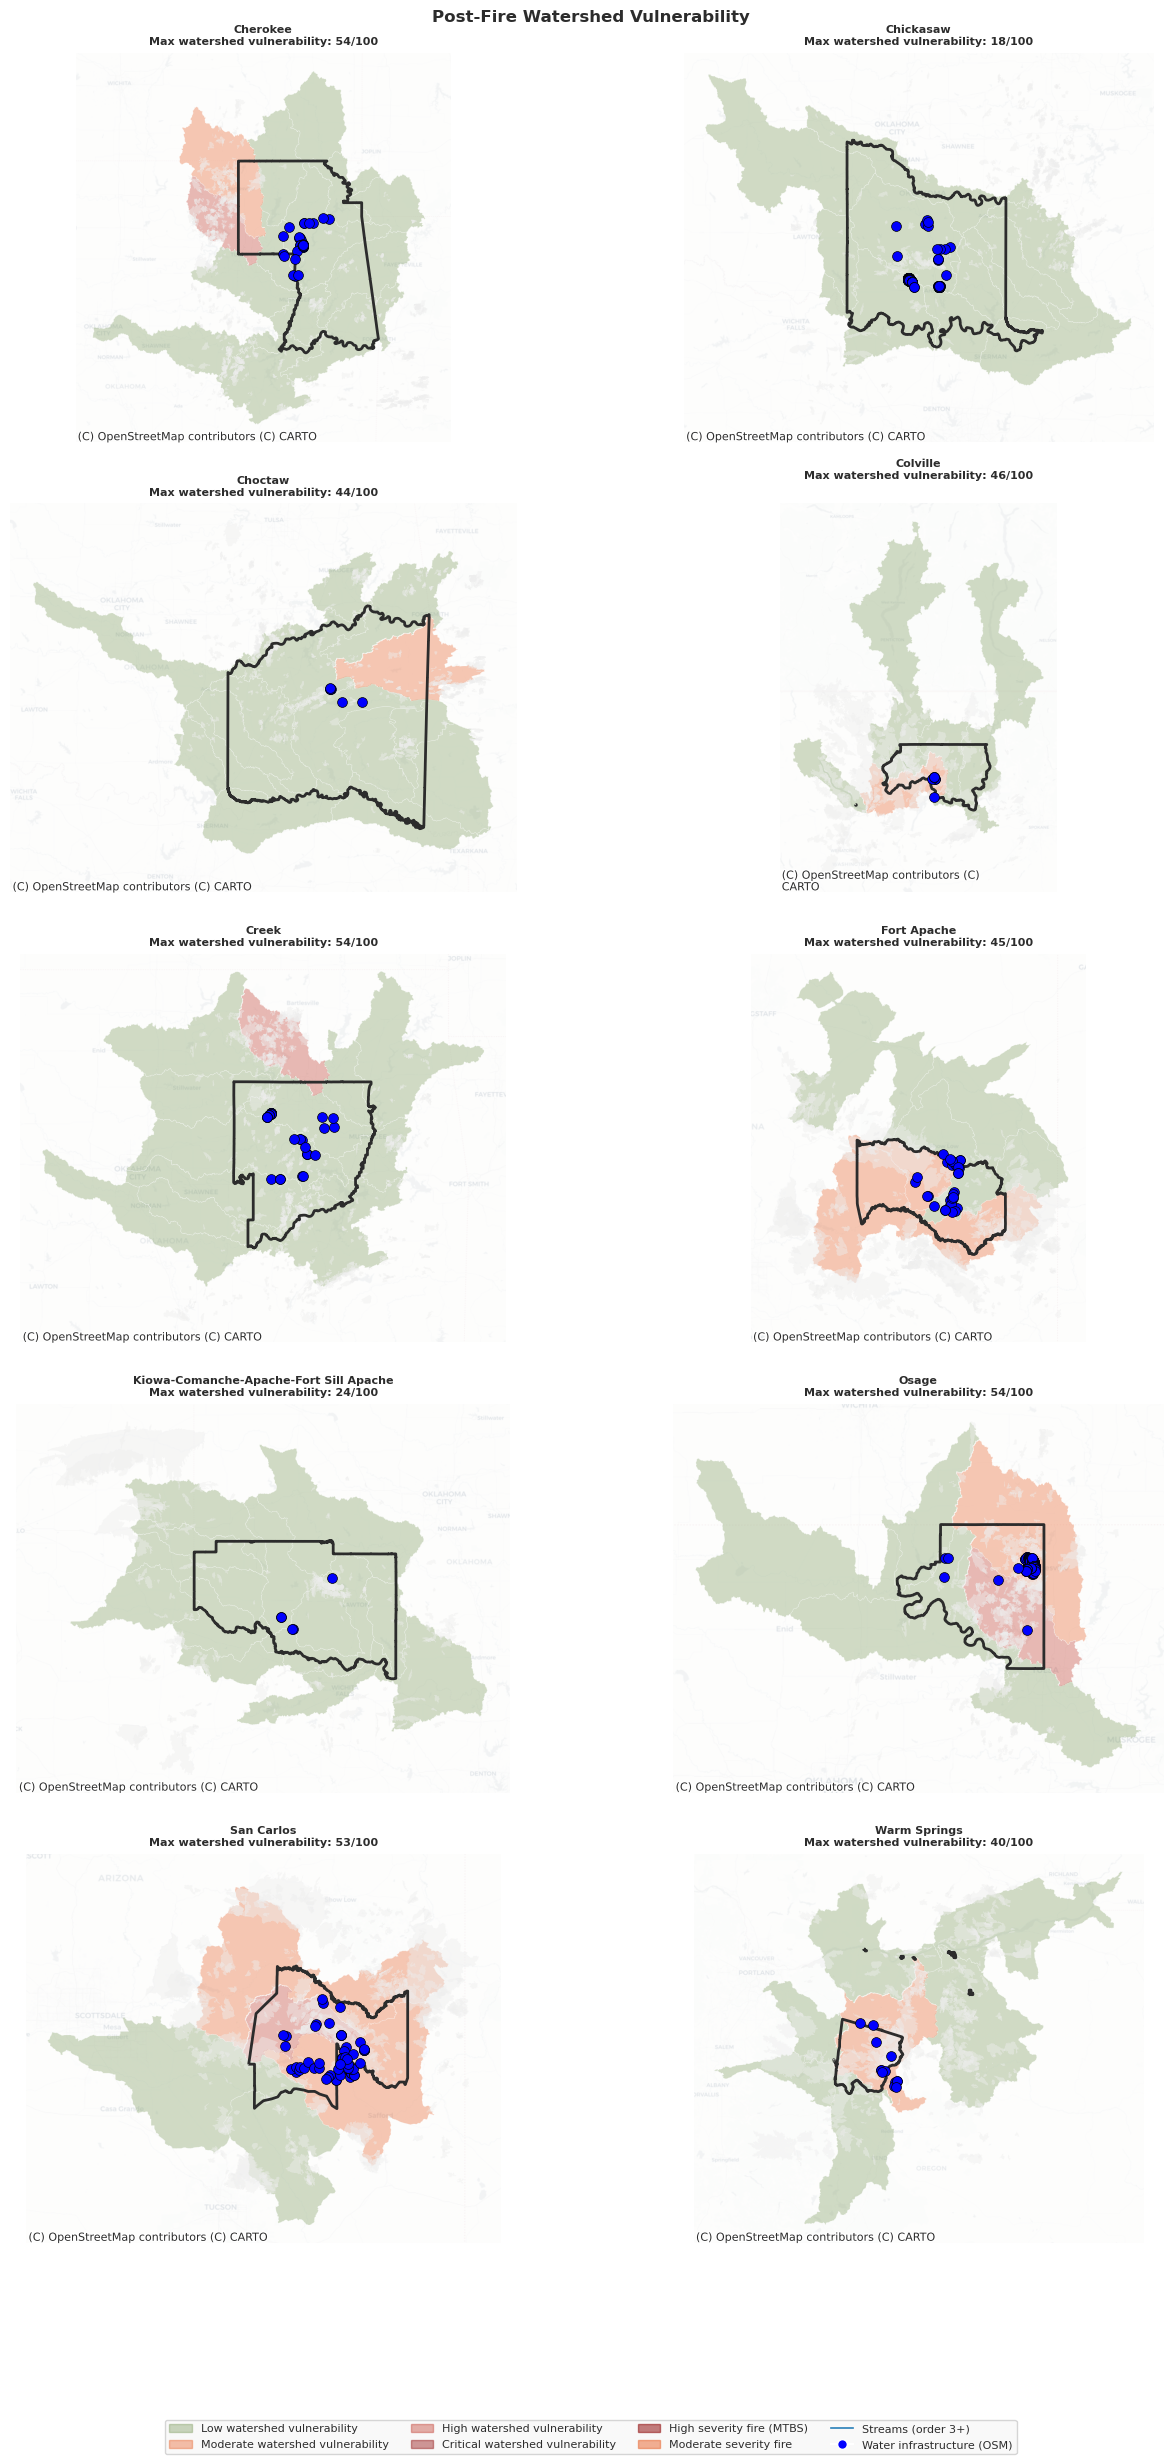

In [13]:
# Per-Tribe watershed vulnerability maps 
VUL_COLORS = {
    "Low":      styles.SAGE_GREEN,
    "Moderate": styles.FIRE_ORANGE,
    "High":     styles.EMBER_RED,
    "Critical": "#8B0000",
}
SEV_COLORS = {
    "High":     "#8B0000",
    "Moderate": styles.FIRE_ORANGE,
    "Low":      styles.SMOKE_GRAY,
    "Unknown":  "#EEEEEE",
}

n_tribes = len(tribal_lands)
ncols, nrows = 2, (n_tribes + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 5))
axes = np.array(axes).flatten()

for i, (_, tribe_row) in enumerate(tribal_lands.iterrows()):
    ax   = axes[i]
    name = tribe_row["NAME"]
    tb   = tribe_row.geometry.bounds
    buf  = 0.5
    clip = geo_utils.bbox_geodataframe(
        (tb[0]-buf, tb[1]-buf, tb[2]+buf, tb[3]+buf)
    ).geometry.iloc[0]

    # Local watersheds
    local_ws = tribal_watersheds[
        tribal_watersheds.apply(lambda r: name in (r["tribes"] or []), axis=1)
    ]
    # Local fires
    local_fires = fire_local[fire_local.intersects(clip)]
    # Local streams
    local_streams = streams_gdf[
        streams_gdf.get("tribal_name", pd.Series()) == name
    ] if not streams_gdf.empty else gpd.GeoDataFrame()

    # Plot watersheds colored by vulnerability
    if not local_ws.empty:
        for cat, color in VUL_COLORS.items():
            sub = local_ws[local_ws["vulnerability_category"] == cat]
            if not sub.empty:
                sub.to_crs(3857).plot(
                    ax=ax, color=color, alpha=0.35,
                    edgecolor="white", linewidth=0.4,
                )

    # MTBS fire perimeters colored by severity
    if not local_fires.empty:
        for sev, color in SEV_COLORS.items():
            sub = local_fires[local_fires["severity_class"] == sev]
            if not sub.empty:
                sub.to_crs(3857).plot(
                    ax=ax, color=color, alpha=0.45,
                    edgecolor="none",
                )

    # Tribal boundary
    gpd.GeoDataFrame(
        geometry=[tribe_row.geometry], crs=constants.CRS_GEOGRAPHIC
    ).to_crs(3857).boundary.plot(
        ax=ax, color=styles.CHARCOAL, linewidth=2, zorder=5
    )

    # Streams
    if not local_streams.empty:
        local_streams.to_crs(3857).plot(
            ax=ax, color=styles.SKY_BLUE, linewidth=0.8, alpha=0.7, zorder=4
        )

    # Water infrastructure
    if not water_infra.empty:
        local_water = water_infra[water_infra.get("tribal_name") == name]
        if not local_water.empty:
            local_water.to_crs(3857).plot(
                ax=ax, color="blue", marker="o",
                markersize=50, edgecolor="black", linewidth=0.5, zorder=6,
            )

    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.3)
    except Exception:
        pass

    ts = tribe_summary[tribe_summary["NAME"] == name]
    mv = ts["max_vulnerability"].iloc[0] if not ts.empty else 0
    ax.set_title(
        f"{name}\nMax watershed vulnerability: {mv:.0f}/100",
        fontsize=8, fontweight="bold",
    )
    ax.set_axis_off()

for ax in axes[n_tribes:]:
    ax.set_visible(False)

fig.legend(
    handles=[
        mpatches.Patch(color=v, alpha=0.4, label=f"{k} watershed vulnerability")
        for k, v in VUL_COLORS.items()
    ] + [
        mpatches.Patch(color="#8B0000", alpha=0.5, label="High severity fire (MTBS)"),
        mpatches.Patch(color=styles.FIRE_ORANGE, alpha=0.5, label="Moderate severity fire"),
        plt.Line2D([0],[0], color=styles.SKY_BLUE, lw=1.2, label="Streams (order 3+)"),
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="blue",
                   markersize=7, label="Water infrastructure (OSM)"),
    ],
    loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, 0),
)
plt.suptitle(
    "Post-Fire Watershed Vulnerability\n",
    #"Watershed color = vulnerability index | Fire perimeters = MTBS severity",
    fontsize=12, fontweight="bold",
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
charts.save_figure(fig, "outputs/figures/watershed_vulnerability_maps.png")
plt.show()

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\watershed_vulnerability_summary.png


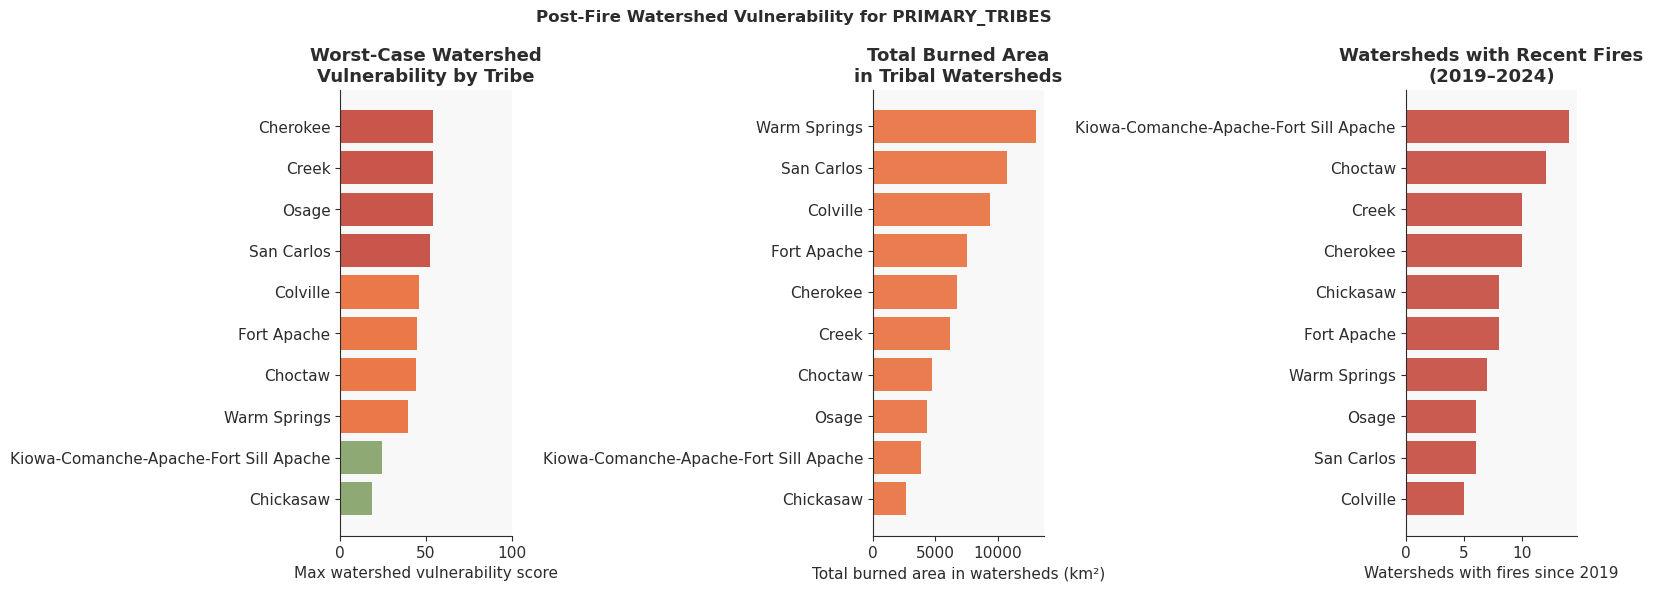

In [14]:
# Vulnerability summary charts 
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Max vulnerability by Tribe
s = tribe_summary.sort_values("max_vulnerability", ascending=True)
axes[0].barh(
    s["NAME"], s["max_vulnerability"],
    color=[
        "#8B0000" if v >= 75 else
        styles.EMBER_RED if v >= 50 else
        styles.FIRE_ORANGE if v >= 25 else
        styles.SAGE_GREEN
        for v in s["max_vulnerability"]
    ],
    alpha=0.85,
)
axes[0].set_xlabel("Max watershed vulnerability score")
axes[0].set_title("Worst-Case Watershed\nVulnerability by Tribe", fontweight="bold")
axes[0].set_xlim(0, 100)
sns.despine(ax=axes[0])

# Burned watershed area
s2 = tribe_summary.sort_values("total_burned_km2", ascending=True)
axes[1].barh(
    s2["NAME"], s2["total_burned_km2"],
    color=styles.FIRE_ORANGE, alpha=0.82,
)
axes[1].set_xlabel("Total burned area in watersheds (km²)")
axes[1].set_title("Total Burned Area\nin Tribal Watersheds", fontweight="bold")
sns.despine(ax=axes[1])

# Recent fire exposure
s3 = tribe_summary.sort_values("n_recent_burns", ascending=True)
axes[2].barh(
    s3["NAME"], s3["n_recent_burns"],
    color=styles.EMBER_RED, alpha=0.82,
)
axes[2].set_xlabel(f"Watersheds with fires since {RECENT_CUTOFF}")
axes[2].set_title(
    f"Watersheds with Recent Fires\n({RECENT_CUTOFF}–{ANALYSIS_YEAR})",
    fontweight="bold",
)
sns.despine(ax=axes[2])

plt.suptitle(
    "Post-Fire Watershed Vulnerability for PRIMARY_TRIBES",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
charts.save_figure(fig, "outputs/figures/watershed_vulnerability_summary.png")
plt.show()

## Exports

In [15]:
# Tabular and spatial exports 
tribe_summary.to_csv(
    constants.OUTPUTS_DIR / "watershed_vulnerability_by_tribe.csv", index=False
)
print("Exported to outputs/watershed_vulnerability_by_tribe.csv")

tribal_watersheds.assign(
    vulnerability_category=lambda df: df["vulnerability_category"].astype(str),
    tribes=lambda df: df["tribes"].apply(
        lambda v: ", ".join(v) if isinstance(v, list) else str(v)
    ),
)[
    ["huc8", "name", "area_km2", "tribes",
     "fire_count", "recent_fire_count", "high_sev_count",
     "pct_watershed_burned", "mean_dnbr",
     "vulnerability_index", "vulnerability_category", "geometry"]
].to_file(
    constants.OUTPUTS_DIR / "tribal_watershed_vulnerability.geojson",
    driver="GeoJSON",
)
print("Exported to outputs/tribal_watershed_vulnerability.geojson")

Exported to outputs/watershed_vulnerability_by_tribe.csv
Exported to outputs/tribal_watershed_vulnerability.geojson


## Summary and Findings

*(Fill in after running with your data.)*

**What the data shows:**
- Which Tribal watersheds have the highest compound vulnerability: high burn
  coverage AND recent fires AND high severity?
- Are Tribal water infrastructure features located downstream of recently
  burned areas? Name those specifically.
- Which Tribes face the largest total burned watershed area?

**Connection to the rest of the series:**
- Cross-reference with `climate_projections_tribal_fire_weather.ipynb`,
  watersheds that already show high post-fire vulnerability and are projected
  to experience more fire weather months are the highest long-term risk.
- Cross-reference with `fast_fire_days_analysis.ipynb`, fast fires create
  post-fire watershed vulnerability faster than suppression can respond.

**Limitations:**
- Burn severity uses mean dNBR from MTBS perimeter attributes, not per-pixel
  raster analysis. For precise erosion risk modeling, download individual
  MTBS severity GeoTIFFs and use slope from 3DEP elevation.
- OSM water infrastructure is incomplete for many Tribal lands. The absence
  of features in the map does not mean absence of infrastructure, it means
  OSM coverage is incomplete.
- Watershed vulnerability does not account for post-fire recovery time.
  Erosion risk peaks in year 1–2 post-fire and declines as vegetation returns.
  `most_recent_year` in the data gives the recency context.

**For Tribal decision makers:**
This analysis supports:
- BIA watershed restoration program funding applications
- EPA Clean Water Act Section 319 nonpoint source program grants
- USDA RCPP (Regional Conservation Partnership Program) applications
- Post-fire BAER (Burned Area Emergency Response) team requests
- Water supply contingency planning with Tribal water resource departments

---
## References

In [16]:
print(generate_citations(["census_aiannh", "mtbs", "usgs_wbd", "nhd_flowlines"]))

References/Data Sources
----------------------------------------
- Census TIGER AIANNH. US Census Bureau. https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
- Monitoring Trends in Burn Severity (MTBS). USGS/USDA Forest Service. https://www.mtbs.gov
- USGS Watershed Boundary Dataset (WBD) HUC-8. US Geological Survey (USGS). https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer
- USGS NHDPlus High Resolution Flowlines. US Geological Survey (USGS). https://hydro.nationalmap.gov/arcgis/rest/services/NHDPlus_HR/MapServer
